In [38]:
import numpy as np
import pandas as pd
import joblib

final_model = joblib.load(
    "../models/aqi_forecasting_model.pkl"
)

df = pd.read_csv(
    "../data/processed/engineered_air_quality.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

In [39]:
num_features = [
    "Valid_AQI",
    "PM2.5",
    "PM10",
    "NO2",
    "CO",
    "SO2",
    "O3",

    "AQI_Lag1",
    "AQI_Lag2",
    "AQI_Lag3",
    "AQI_Lag7",
    "AQI_Roll3",
    "AQI_Roll7",

    "PM2.5_Lag1",
    "PM10_Lag1",
    "NO2_Lag1",
    "CO_Lag1",
    "SO2_Lag1",
    "O3_Lag1",

    "AQI_Change1",
    "PM25_Change1",

    "Month_Sin",
    "Month_Cos",
    "DayOfYear_Sin",
    "DayOfYear_Cos"
]

cat_features = [
    "City",
    "Season",
    "DayOfWeek"
]

features = num_features + cat_features

In [40]:
test_df = df[
    df["Date"] >= "2020-01-01"
].copy()

X_test = test_df[features]
y_test = test_df["Target_AQI"]

In [41]:
preprocessor = final_model.named_steps["preprocessor"]
xgb = final_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

len(feature_names)

48

In [42]:
importance = xgb.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__PM2.5,0.520227
0,num__Valid_AQI,0.103200
29,cat__City_Delhi,0.062415
2,num__PM10,0.019632
27,cat__City_Bengaluru,0.018660
8,num__AQI_Lag2,0.014931
12,num__AQI_Roll7,0.013621
28,cat__City_Chennai,0.011954
11,num__AQI_Roll3,0.010928
20,num__PM25_Change1,0.010204


In [43]:
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

In [44]:
import plotly.express as px

top_features = importance_df.head(15)

fig = px.bar(
    top_features,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top Features Used by the AQI Forecasting Model"
)

fig.update_yaxes(
    categoryorder="total ascending"
)

fig.show()

In [45]:
import shap

In [46]:
X_test_transformed = preprocessor.transform(X_test)

In [47]:
rng = np.random.RandomState(42)

idx = rng.choice(
    len(X_test),
    size=min(500, len(X_test)),
    replace=False
)

X_shap = X_test_transformed[idx]

In [48]:
if hasattr(X_shap, "toarray"):
    X_shap = X_shap.toarray()

In [49]:
X_shap = pd.DataFrame(
    X_shap,
    columns=feature_names
)

In [50]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer(X_shap)

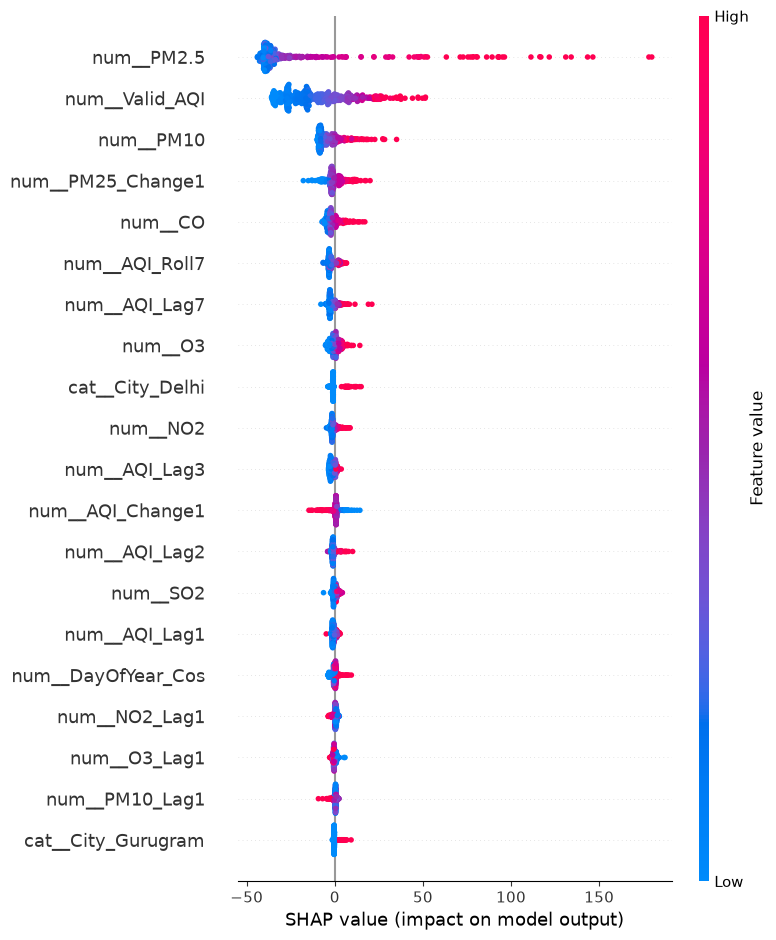

In [51]:
shap.summary_plot(
    shap_values.values,
    X_shap,
    feature_names=feature_names
)

In [52]:
clean_feature_names = [
    x.replace("num__", "").replace("cat__", "")
    for x in feature_names
]

In [53]:
row = 50

actual_index = idx[row]

print(
    "City:",
    test_df.iloc[actual_index]["City"]
)

print(
    "Date:",
    test_df.iloc[actual_index]["Date"]
)

print(
    "Actual tomorrow AQI:",
    test_df.iloc[actual_index]["Target_AQI"]
)

print(
    "Predicted AQI:",
    final_model.predict(
        X_test.iloc[[actual_index]]
    )[0]
)

City: Bengaluru
Date: 2020-06-26 00:00:00
Actual tomorrow AQI: 51.0
Predicted AQI: 55.680447


In [54]:
import sqlite3

con = sqlite3.connect("../data/airlens.db")

aq = pd.read_sql_query(
    "SELECT * FROM air_quality_validated",
    con
)

con.close()

aq["Date"] = pd.to_datetime(aq["Date"])

In [55]:
reliable_cities = [
    "Amaravati",
    "Amritsar",
    "Bengaluru",
    "Chennai",
    "Delhi",
    "Gurugram",
    "Hyderabad",
    "Jaipur",
    "Kolkata",
    "Lucknow",
    "Thiruvananthapuram",
    "Visakhapatnam"
]

In [56]:
aq = aq[
    aq["City"].isin(reliable_cities)
].copy()

In [57]:
anomaly_train = aq[
    aq["Date"] < "2020-01-01"
].copy()

anomaly_test = aq[
    aq["Date"] >= "2020-01-01"
].copy()

In [58]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [59]:
anomaly_features = [
    "Valid_AQI",
    "PM2.5",
    "PM10",
    "NO2",
    "CO",
    "SO2",
    "O3"
]

In [60]:
train_anomaly = df[
    df["Date"] < "2020-01-01"
].copy()

test_anomaly = df[
    df["Date"] >= "2020-01-01"
].copy()

In [61]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [62]:
anomaly_results = []

cities = test_anomaly["City"].unique()

for city in cities:

    train_city = train_anomaly[
        train_anomaly["City"] == city
    ].copy()

    test_city = test_anomaly[
        test_anomaly["City"] == city
    ].copy()

    if len(train_city) < 100:
        continue

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "detector",
            IsolationForest(
                n_estimators=300,
                contamination=0.02,
                random_state=42
            )
        )
    ])

    model.fit(
        train_city[anomaly_features]
    )

    pred = model.predict(
        test_city[anomaly_features]
    )

    score = model.decision_function(
        test_city[anomaly_features]
    )

    temp = test_city[
        ["City", "Date", "Valid_AQI"]
    ].copy()

    temp["Anomaly"] = pred
    temp["Anomaly_Score"] = score

    anomaly_results.append(temp)

c:\lg_G\Air_Quality_Analytics\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['PM10']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\lg_G\Air_Quality_Analytics\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['PM10']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\lg_G\Air_Quality_Analytics\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['PM10']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [63]:
anomalies = pd.concat(
    anomaly_results,
    ignore_index=True
)

In [64]:
anomalies["Is_Anomaly"] = (
    anomalies["Anomaly"] == -1
)

In [65]:
anomalies["Is_Anomaly"].value_counts()

Is_Anomaly
False    2160
True       10
Name: count, dtype: int64

In [66]:
anomalies[
    anomalies["Is_Anomaly"]
].sort_values(
    "Anomaly_Score"
).head(20)

,City,Date,Valid_AQI,Anomaly,Anomaly_Score,Is_Anomaly
2006,Visakhapatnam,2020-01-14,326.0,-1,-0.084518,True
1629,Lucknow,2020-01-01,442.0,-1,-0.072097,True
550,Chennai,2020-01-14,230.0,-1,-0.068425,True
1851,Thiruvananthapuram,2020-02-10,215.0,-1,-0.054288,True
327,Amritsar,2020-06-03,478.0,-1,-0.035447,True
1630,Lucknow,2020-01-02,361.0,-1,-0.022313,True
1640,Lucknow,2020-01-12,377.0,-1,-0.016918,True
213,Amritsar,2020-02-03,NaN,-1,-0.007055,True
635,Chennai,2020-04-08,55.0,-1,-0.002612,True
1635,Lucknow,2020-01-07,308.0,-1,-0.002260,True


In [67]:
city_anomalies = (
    anomalies[
        anomalies["Is_Anomaly"]
    ]
    .groupby("City")
    .size()
    .reset_index(name="Anomaly_Days")
)

city_anomalies.sort_values(
    "Anomaly_Days",
    ascending=False
)

,City,Anomaly_Days
2,Lucknow,4
0,Amritsar,2
1,Chennai,2
3,Thiruvananthapuram,1
4,Visakhapatnam,1


In [68]:
fig = px.bar(
    city_anomalies.sort_values(
        "Anomaly_Days",
        ascending=False
    ),
    x="City",
    y="Anomaly_Days",
    title="Detected Pollution Anomalies by City"
)

fig.show()

In [69]:
delhi = anomalies[
    anomalies["City"] == "Delhi"
].copy()

fig = px.line(
    delhi,
    x="Date",
    y="Valid_AQI",
    title="Delhi AQI with Detected Pollution Anomalies"
)

anomaly_points = delhi[
    delhi["Is_Anomaly"]
]

fig.add_scatter(
    x=anomaly_points["Date"],
    y=anomaly_points["Valid_AQI"],
    mode="markers",
    name="Anomaly"
)

fig.show()